<a href="https://colab.research.google.com/github/Ashwin126/Test1/blob/main/01_prompt_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Session 2 — Prompt Engineering for Analysts

**Dataset:** Supermart Grocery Sales - Retail Analytics Dataset (Kaggle, mohamedharris)

**Business question for this session:** Does giving deeper discounts hurt profit margin?

We'll ask Claude the same underlying question three ways and compare what comes back.

## Setup

### Upload Missing CSV File

To resolve the `FileNotFoundError`, please upload the `Supermart Grocery Sales - Retail Analytics Dataset.csv` file to your Colab environment. You can do this by clicking the 'Files' icon on the left sidebar, then clicking 'Upload to session storage' (the icon with an upward arrow).

Alternatively, if you have a direct download link for the CSV file (e.g., from Kaggle), you can use the following code cell to download it directly. **Remember to replace `YOUR_DOWNLOAD_LINK_HERE` with the actual URL.**

In [4]:
# Example for downloading the file if you have a direct link:
# import requests
# url = 'YOUR_DOWNLOAD_LINK_HERE' # Replace with the actual URL to the CSV file
# response = requests.get(url)
# with open('Supermart Grocery Sales - Retail Analytics Dataset.csv', 'wb') as f:
#     f.write(response.content)
# print('File downloaded successfully.')

# If you have manually uploaded the file, you can skip this cell.


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohamedharris/supermart-grocery-sales-retail-analytics-dataset")

print("Path to dataset files:", path)

100%|██████████| 191k/191k [00:00<00:00, 52.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mohamedharris/supermart-grocery-sales-retail-analytics-dataset/versions/2


**Instructor note:** the raw `Order Date` column silently mixes two date formats (`11-08-2017` and `4/15/2018`). Naively calling `pd.to_datetime()` on the whole column throws an error — a good 30-second live moment: ask Claude to fix it, then check *why* the fix works instead of pasting it blindly.

## Prompt 1 — Vague

> Prompt: *"does discount affect profit?"*

Try this in Claude. It will likely return a generic, textbook-sounding answer about discounts eroding margin — **without looking at this dataset at all.** That's the trap: it sounds plausible and isn't grounded in the data in front of you.

## Prompt 2 — Specific

> Prompt: *"Using this dataframe, calculate the correlation between Discount and Margin (Profit/Sales) at the row level."*

In [7]:
df[["Discount", "Margin", "Profit"]].corr()

,Discount,Margin,Profit
Discount,1.000000,0.008282,0.000017
Margin,0.008282,1.000000,0.747300
Profit,0.000017,0.747300,1.000000


**Real output:** correlation between `Discount` and `Margin` is **~0.008** — essentially zero. Discount level does not meaningfully predict profit margin in this dataset.

## Prompt 3 — Leading

> Prompt: *"Discounting is clearly hurting our margins here, right?"*

Try this one live. Claude will often agree with the premise and generate a confident explanation for *why* — even though the correlation above says otherwise. **This is the teaching moment**: a leading question gets a leading answer.

## Category-level check (does the answer hold up?)

In [8]:
cat = df.groupby("Category").agg(Sales=("Sales","sum"), Profit=("Profit","sum"), Discount=("Discount","mean"))
cat["Margin"] = cat["Profit"] / cat["Sales"]
cat.sort_values("Margin")

,Sales,Profit,Discount,Margin
Category,,,,
Oil & Masala,2038442,497895.29,0.224526,0.244253
Food Grains,2115272,529162.64,0.228548,0.250163
Bakery,2112281,528521.06,0.225428,0.250213
"Eggs, Meat & Fish",2267401,567357.22,0.227792,0.250224
Beverages,2085313,525605.76,0.230329,0.252051
Fruits & Veggies,2100727,530400.38,0.229295,0.252484
Snacks,2237546,568178.85,0.222048,0.253929


Margins sit in a tight **24-25% band across all 7 categories** regardless of average discount per category. The vague and leading prompts both would have missed this.

## Student deliverable

Prepare **one slide** (or a single markdown cell formatted like one) with:
1. Your business question
2. The three prompts you tried and what changed
3. Your answer
4. Your trust check — what did you verify before believing it?

2-3 students will be cold-called to present, ~2 minutes each.

In [9]:
import pandas as pd
import os

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, "Supermart Grocery Sales - Retail Analytics Dataset.csv")

df = pd.read_csv(csv_file_path)

def parse_date(s):
    return pd.to_datetime(s, format="%d-%m-%Y") if "-" in s else pd.to_datetime(s, format="%m/%d/%Y")

df["Order Date"] = df["Order Date"].apply(parse_date)
df["Margin"] = df["Profit"] / df["Sales"]
df.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State,Margin
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-08-11,North,1254,0.12,401.28,Tamil Nadu,0.32
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-08-11,South,749,0.18,149.80,Tamil Nadu,0.20
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-12-06,West,2360,0.21,165.20,Tamil Nadu,0.07
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,2016-11-10,South,896,0.25,89.60,Tamil Nadu,0.10
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,2016-11-10,South,2355,0.26,918.45,Tamil Nadu,0.39


/tmp/ipykernel_697/1918073720.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sales_by_month = df.set_index('Order Date').resample('M')['Sales'].sum()


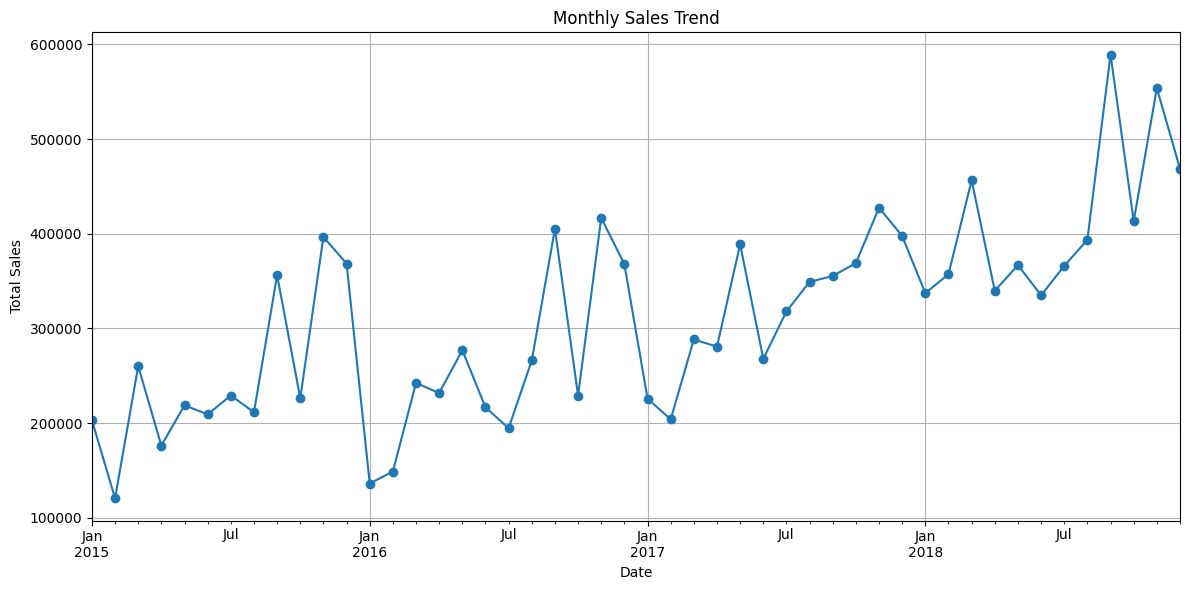

Total Sales across all orders: $14,956,982.00


In [10]:
import matplotlib.pyplot as plt

# Calculate total sales
total_sales = df['Sales'].sum()

# Get sales over time by month
sales_by_month = df.set_index('Order Date').resample('M')['Sales'].sum()

# Plot monthly sales trend
plt.figure(figsize=(12, 6))
sales_by_month.plot(kind='line', marker='o', linestyle='-')
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

# Display total sales
print(f"Total Sales across all orders: ${total_sales:,.2f}")

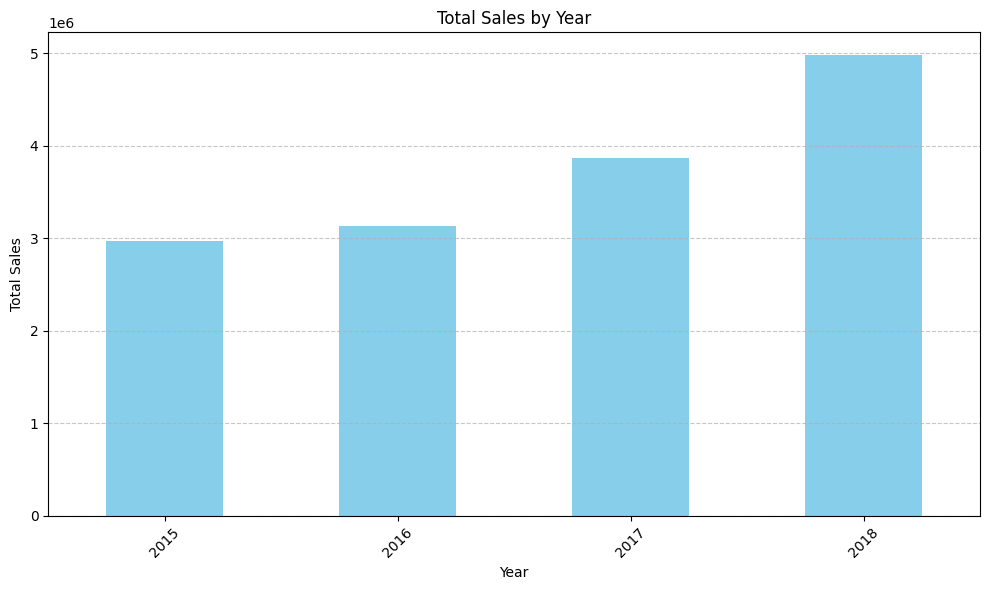

In [11]:
import matplotlib.pyplot as plt

# Extract year from 'Order Date'
df['Order Year'] = df['Order Date'].dt.year

# Aggregate sales by year
sales_by_year = df.groupby('Order Year')['Sales'].sum()

# Plot yearly sales trend
plt.figure(figsize=(10, 6))
sales_by_year.plot(kind='bar', color='skyblue')
plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# Calculate year-over-year growth percentage
yoy_growth = sales_by_year.pct_change() * 100

print("Year-over-Year Sales Growth (%):")
print(yoy_growth.dropna())

Year-over-Year Sales Growth (%):
Order Year
2016     5.254740
2017    23.625884
2018    28.554368
Name: Sales, dtype: float64


### Sales Growth by Category

Year-over-Year Sales Growth by Category (%):


Order Year,2016,2017,2018
Category,,,
Bakery,12.439772,3.339994,36.054797
Beverages,4.064621,27.683989,30.051603
"Eggs, Meat & Fish",-4.332874,22.301674,34.004895
Food Grains,22.997219,38.884887,16.600967
Fruits & Veggies,14.473916,10.238002,36.846243
Oil & Masala,-2.640369,36.700224,13.010904
Snacks,-5.089045,30.418410,35.750977


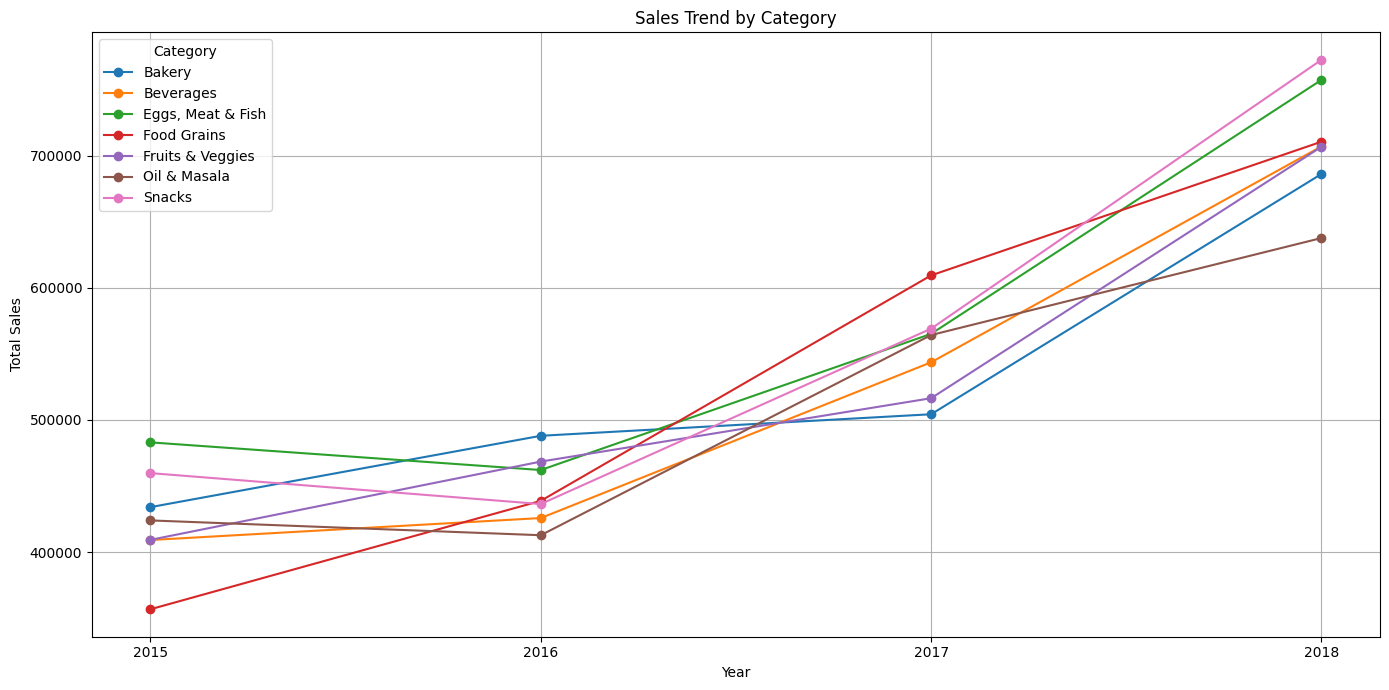

In [13]:
# Aggregate sales by category and year
sales_by_category_year = df.groupby(['Category', 'Order Year'])['Sales'].sum().unstack(fill_value=0)

# Calculate year-over-year growth for each category
category_yoy_growth = sales_by_category_year.pct_change(axis=1) * 100

print("Year-over-Year Sales Growth by Category (%):")
display(category_yoy_growth.dropna(axis=1))

# Visualize sales by category over years
sales_by_category_year.T.plot(kind='line', marker='o', figsize=(14, 7))
plt.title('Sales Trend by Category')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(sales_by_category_year.columns)
plt.tight_layout()
plt.show()

### Sales Growth by Region

Year-over-Year Sales Growth by Region (%):


Order Year,2017,2018
Region,,
Central,29.002637,29.675431
East,16.632011,21.116809
North,inf,-100.000000
South,23.111943,24.343132
West,26.947100,37.014088


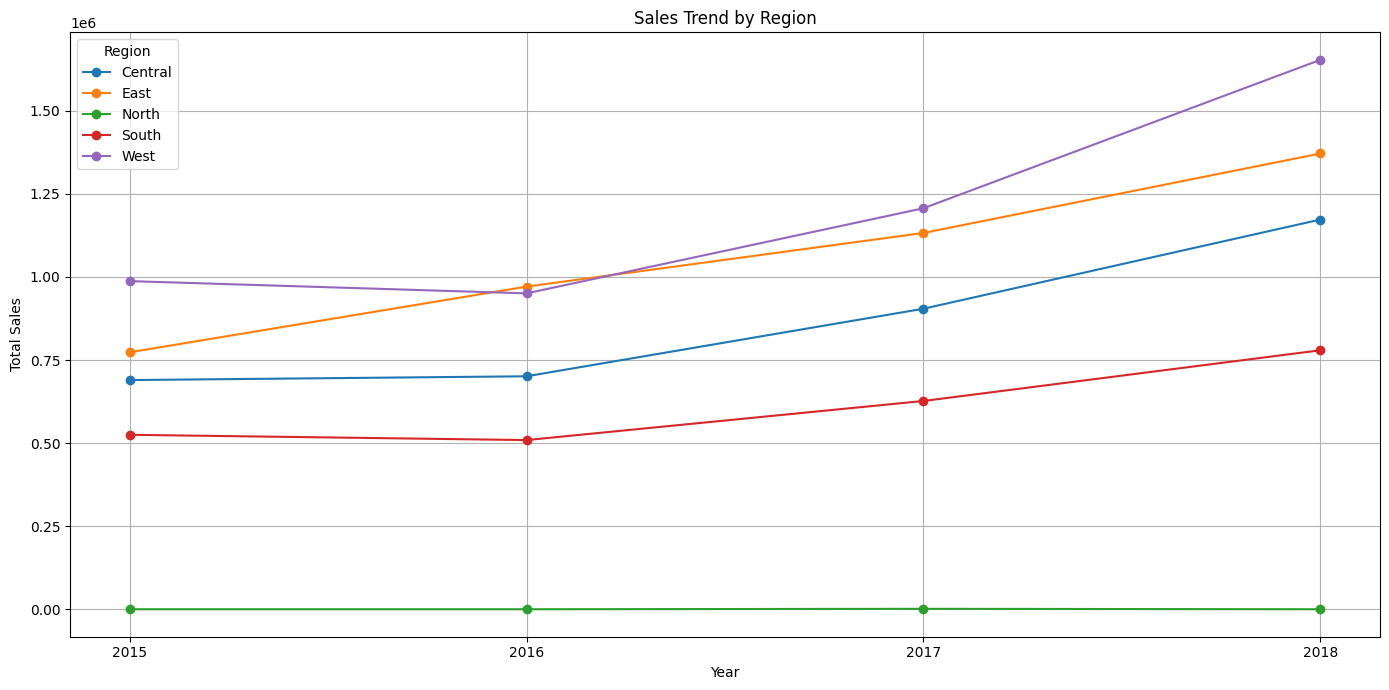

In [14]:
# Aggregate sales by region and year
sales_by_region_year = df.groupby(['Region', 'Order Year'])['Sales'].sum().unstack(fill_value=0)

# Calculate year-over-year growth for each region
region_yoy_growth = sales_by_region_year.pct_change(axis=1) * 100

print("Year-over-Year Sales Growth by Region (%):")
display(region_yoy_growth.dropna(axis=1))

# Visualize sales by region over years
sales_by_region_year.T.plot(kind='line', marker='o', figsize=(14, 7))
plt.title('Sales Trend by Region')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(sales_by_region_year.columns)
plt.tight_layout()
plt.show()

### Sales Trend for 'Fruits & Veggies' Category

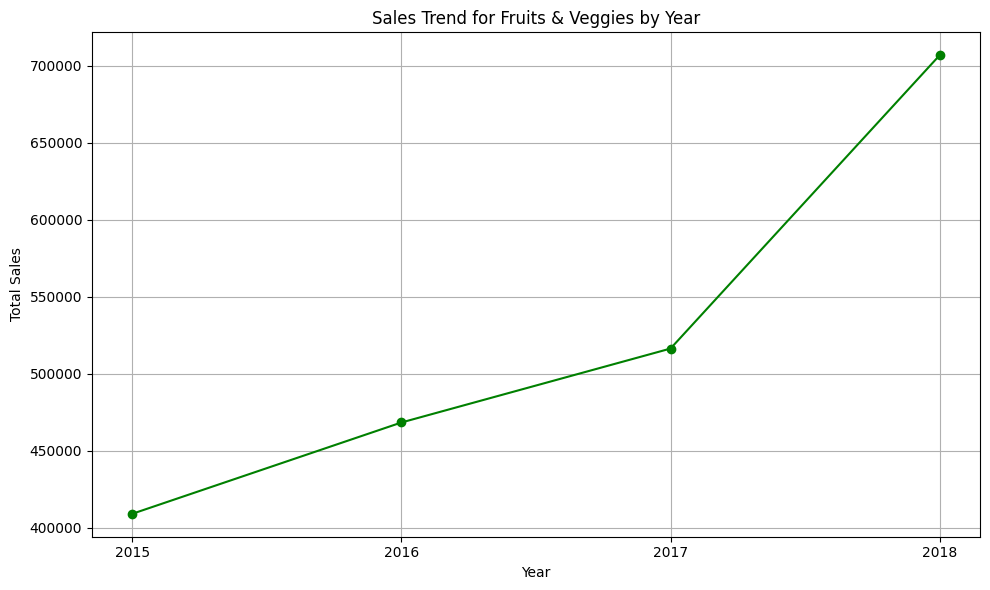

Sales for 'Fruits & Veggies' by Year:
Order Year
2015    409212
2016    468441
2017    516400
2018    706674
Name: Fruits & Veggies, dtype: int64


In [15]:
import matplotlib.pyplot as plt

# Get sales data for 'Fruits & Veggies' category
fruits_veggies_sales = sales_by_category_year.loc['Fruits & Veggies']

# Plot the sales trend
plt.figure(figsize=(10, 6))
fruits_veggies_sales.plot(kind='line', marker='o', color='green')
plt.title('Sales Trend for Fruits & Veggies by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid(True)
plt.xticks(fruits_veggies_sales.index)
plt.tight_layout()
plt.show()

print("Sales for 'Fruits & Veggies' by Year:")
print(fruits_veggies_sales)